In [1]:
import pandas as pd

columns = [
    "player_id",
    "player_name",
    "matches_played",
    "total_runs",
    "balls_faced",
    "total_fours",
    "total_sixes",
    "strike_rate",
    "centuries",
    "half_centuries",
    "ducks",
    "total_wickets",
    "bowling_economy",
    "performance_score",
    "auction_value"
]

df = pd.read_csv("/content/Results 39.csv", header=None, names=columns)

df.head()

,player_id,player_name,matches_played,total_runs,balls_faced,total_fours,total_sixes,strike_rate,centuries,half_centuries,ducks,total_wickets,bowling_economy,performance_score,auction_value
0,1,AJ Finch,90,2092,1635,214,78,127.95,0,15,7,1,10.858,1140.60,1.50
1,2,AM Rahane,171,4642,3761,479,103,123.42,2,30,13,1,5.000,2380.14,0.50
2,3,AT Rayudu,185,4348,3409,359,173,127.54,1,22,13,0,0.000,2298.95,6.75
3,4,BB McCullum,109,2882,2190,293,130,131.60,2,13,6,0,0.000,1579.96,3.60
4,5,CA Pujara,22,390,391,50,4,99.74,0,1,1,0,0.000,181.97,1.90


In [2]:
X = df[columns]
y = df["auction_value"]

In [3]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [4]:
print("Rows and columns:", df.shape)

print("\nColumns:")
print(df.columns)

print("\nMissing values:")
print(df.isnull().sum())

Rows and columns: (39, 15)

Columns:
Index(['player_id', 'player_name', 'matches_played', 'total_runs',
       'balls_faced', 'total_fours', 'total_sixes', 'strike_rate', 'centuries',
       'half_centuries', 'ducks', 'total_wickets', 'bowling_economy',
       'performance_score', 'auction_value'],
      dtype='object')

Missing values:
player_id            0
player_name          0
matches_played       0
total_runs           0
balls_faced          0
total_fours          0
total_sixes          0
strike_rate          0
centuries            0
half_centuries       0
ducks                0
total_wickets        0
bowling_economy      0
performance_score    0
auction_value        0
dtype: int64


In [5]:
feature_columns = [
    "matches_played",
    "total_runs",
    "balls_faced",
    "total_fours",
    "total_sixes",
    "strike_rate",
    "centuries",
    "half_centuries",
    "ducks",
    "total_wickets",
    "bowling_economy",
    "performance_score"
]

X = df[feature_columns]
y = df["auction_value"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (39, 12)
Target shape: (39,)


In [6]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (31, 12)
Testing data: (8, 12)


In [7]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Training data after scaling:", X_train_scaled.shape)
print("Testing data after scaling:", X_test_scaled.shape)

Training data after scaling: (31, 12)
Testing data after scaling: (8, 12)


In [8]:
from sklearn.linear_model import LinearRegression

linear_model = LinearRegression()

linear_model.fit(X_train_scaled, y_train)

y_pred_linear = linear_model.predict(X_test_scaled)

print("Linear Regression model trained successfully.")

Linear Regression model trained successfully.


In [9]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae_linear = mean_absolute_error(y_test, y_pred_linear)

rmse_linear = np.sqrt(
    mean_squared_error(y_test, y_pred_linear)
)

r2_linear = r2_score(y_test, y_pred_linear)

print("Linear Regression")
print("MAE :", mae_linear)
print("RMSE:", rmse_linear)
print("R²  :", r2_linear)

Linear Regression
MAE : 2.900186120291967
RMSE: 4.326844480557389
R²  : -0.21662845106072415


In [10]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train_scaled, y_train)

y_pred_rf = rf_model.predict(X_test_scaled)

print("Random Forest model trained successfully.")

Random Forest model trained successfully.


In [11]:
mae_rf = mean_absolute_error(y_test, y_pred_rf)

rmse_rf = np.sqrt(
    mean_squared_error(y_test, y_pred_rf)
)

r2_rf = r2_score(y_test, y_pred_rf)

print("Random Forest")
print("MAE :", mae_rf)
print("RMSE:", rmse_rf)
print("R²  :", r2_rf)

Random Forest
MAE : 2.848725
RMSE: 4.167428754040073
R²  : -0.12863045414091112


In [12]:
from xgboost import XGBRegressor

xgb_model = XGBRegressor(
    n_estimators=100,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

xgb_model.fit(X_train_scaled, y_train)

y_pred_xgb = xgb_model.predict(X_test_scaled)

print("XGBoost model trained successfully.")

XGBoost model trained successfully.


In [13]:
mae_xgb = mean_absolute_error(y_test, y_pred_xgb)

rmse_xgb = np.sqrt(
    mean_squared_error(y_test, y_pred_xgb)
)

r2_xgb = r2_score(y_test, y_pred_xgb)

print("XGBoost")
print("MAE :", mae_xgb)
print("RMSE:", rmse_xgb)
print("R²  :", r2_xgb)

XGBoost
MAE : 2.9968785524368284
RMSE: 4.592903701098044
R²  : -0.37085044190929684


In [14]:
results = pd.DataFrame({
    "Actual_Auction_Value": y_test.values,
    "Predicted_Auction_Value": y_pred_rf
})

print(results)

   Actual_Auction_Value  Predicted_Auction_Value
0                  4.00                   5.9604
1                  0.20                   3.5366
2                  1.90                   4.0022
3                  5.50                   6.9109
4                  5.40                   4.9957
5                  4.40                   5.4381
6                  7.00                   5.0742
7                 14.25                   3.6385


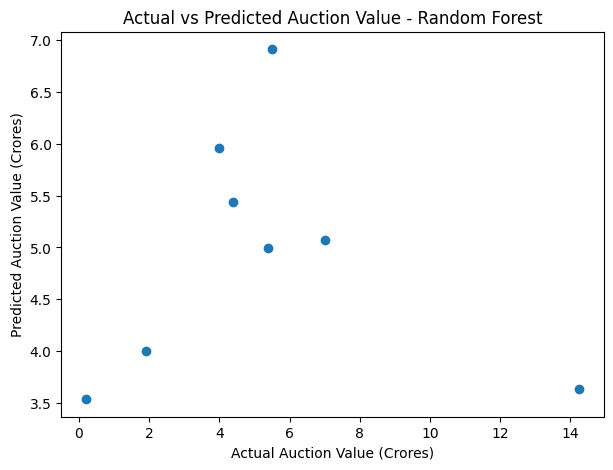

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 5))

plt.scatter(y_test, y_pred_rf)

plt.xlabel("Actual Auction Value (Crores)")
plt.ylabel("Predicted Auction Value (Crores)")
plt.title("Actual vs Predicted Auction Value - Random Forest")

plt.show()

In [16]:
feature_importance = pd.DataFrame({
    "Feature": feature_columns,
    "Importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print(feature_importance)

              Feature  Importance
5         strike_rate    0.240981
0      matches_played    0.154479
10    bowling_economy    0.102001
4         total_sixes    0.085977
11  performance_score    0.078136
2         balls_faced    0.067489
9       total_wickets    0.065151
8               ducks    0.061351
7      half_centuries    0.057900
1          total_runs    0.036581
3         total_fours    0.028912
6           centuries    0.021043


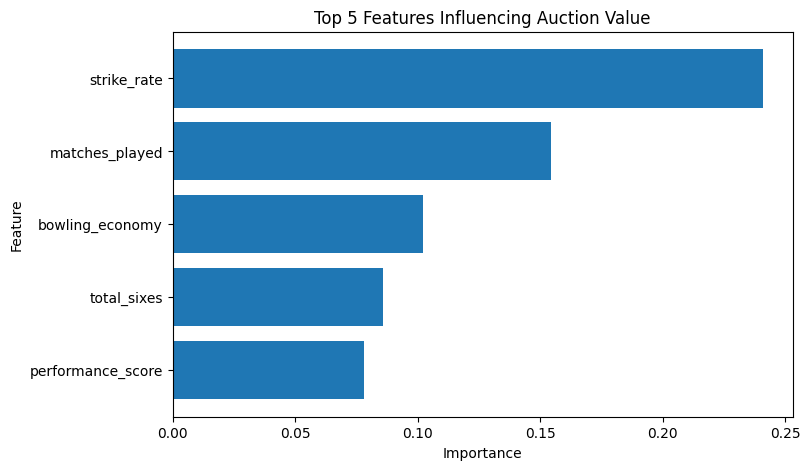

In [17]:
top_5 = feature_importance.head(5)

plt.figure(figsize=(8, 5))

plt.barh(top_5["Feature"], top_5["Importance"])

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 5 Features Influencing Auction Value")

plt.gca().invert_yaxis()

plt.show()

In [18]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(random_state=42)

param_grid = {
    "n_estimators": [200, 500],
    "max_depth": [2, 3, 5],
    "min_samples_leaf": [1, 2, 3]
}

grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,
    scoring="neg_mean_absolute_error"
)

grid_search.fit(X_train_scaled, y_train)

print("Best parameters:", grid_search.best_params_)
print("Best CV MAE:", -grid_search.best_score_)

Best parameters: {'max_depth': 2, 'min_samples_leaf': 3, 'n_estimators': 200}
Best CV MAE: 2.7416594687285754


In [19]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

tuned_rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=2,
    min_samples_leaf=3,
    random_state=42
)

tuned_rf.fit(X_train_scaled, y_train)

y_pred_tuned = tuned_rf.predict(X_test_scaled)

mae_tuned = mean_absolute_error(y_test, y_pred_tuned)
rmse_tuned = np.sqrt(mean_squared_error(y_test, y_pred_tuned))
r2_tuned = r2_score(y_test, y_pred_tuned)

print("Tuned Random Forest")
print("MAE :", mae_tuned)
print("RMSE:", rmse_tuned)
print("R²  :", r2_tuned)

Tuned Random Forest
MAE : 2.6586310137874447
RMSE: 3.907061631730384
R²  : 0.007990294820272248


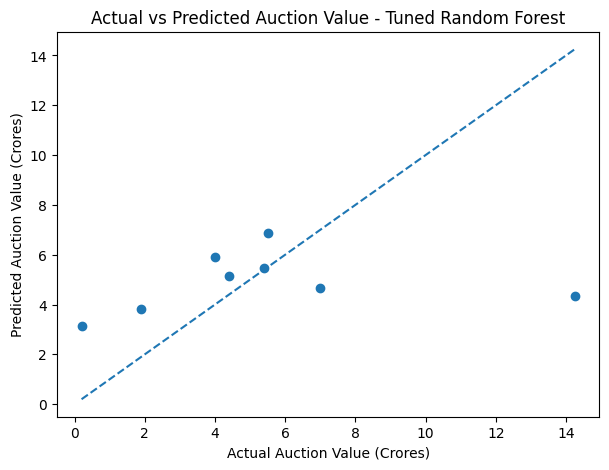

In [20]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 5))

plt.scatter(y_test, y_pred_tuned)

# Perfect prediction line
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--"
)

plt.xlabel("Actual Auction Value (Crores)")
plt.ylabel("Predicted Auction Value (Crores)")
plt.title("Actual vs Predicted Auction Value - Tuned Random Forest")

plt.show()

In [21]:
sample_players = df.head(5)

X_sample = sample_players[feature_columns]

X_sample_scaled = scaler.transform(X_sample)

predicted_values = tuned_rf.predict(X_sample_scaled)

prediction_results = pd.DataFrame({
    "Player": sample_players["player_name"],
    "Actual Auction Value": sample_players["auction_value"],
    "Predicted Auction Value": predicted_values
})

print(prediction_results)

        Player  Actual Auction Value  Predicted Auction Value
0     AJ Finch                  1.50                 3.166207
1    AM Rahane                  0.50                 3.355616
2    AT Rayudu                  6.75                 5.733249
3  BB McCullum                  3.60                 5.212133
4    CA Pujara                  1.90                 3.834923


In [22]:
final_feature_importance = pd.DataFrame({
    "Feature": feature_columns,
    "Importance": tuned_rf.feature_importances_
})

final_feature_importance = final_feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print(final_feature_importance)

              Feature  Importance
5         strike_rate    0.299827
0      matches_played    0.194293
4         total_sixes    0.117839
10    bowling_economy    0.082159
11  performance_score    0.076900
2         balls_faced    0.066836
9       total_wickets    0.062685
7      half_centuries    0.034245
1          total_runs    0.028915
8               ducks    0.021163
3         total_fours    0.009355
6           centuries    0.005782


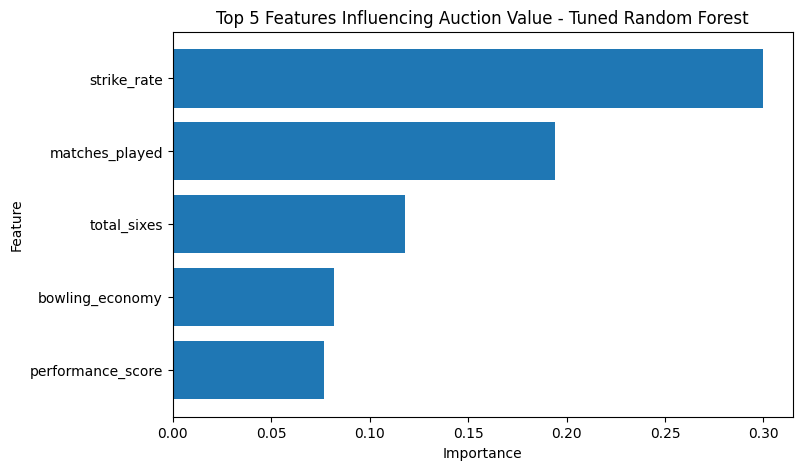

In [23]:
top_5_final = final_feature_importance.head(5)

plt.figure(figsize=(8, 5))

plt.barh(top_5_final["Feature"], top_5_final["Importance"])

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 5 Features Influencing Auction Value - Tuned Random Forest")

plt.gca().invert_yaxis()

plt.show()

## Final ML Findings

This project was developed to estimate IPL player auction value using historical player performance statistics. The model used 39 players who had a valid auction or RTM purchase value. Virat Kohli was excluded from the ML dataset because his available ₹0.12 crore value was from the U19 draft rather than a genuine auction or RTM purchase.

The input features used for prediction were matches played, total runs, balls faced, total fours, total sixes, strike rate, centuries, half-centuries, ducks, total wickets, bowling economy, and performance score. The target variable was auction value in crores.

Three regression models were tested: Linear Regression, Random Forest, and XGBoost. Initially, Linear Regression produced an MAE of 2.90 crores, RMSE of 4.33 crores, and an R² of -0.217. Random Forest performed slightly better, with an MAE of 2.85 crores, RMSE of 4.17 crores, and an R² of -0.129. XGBoost produced an MAE of 3.00 crores, RMSE of 4.59 crores, and an R² of -0.371.

Random Forest was then tuned by testing different model settings. The tuned Random Forest achieved an MAE of 2.66 crores, RMSE of 3.91 crores, and an R² of 0.008. Therefore, the tuned Random Forest was selected as the best model among the three tested models.

The feature importance analysis showed that strike rate was the most influential feature in the tuned Random Forest model. Matches played, total sixes, bowling economy, and performance score were the next four most influential features. This suggests that the model gave relatively more importance to scoring ability, experience, power hitting, bowling efficiency, and overall performance.

However, the model has an important limitation. Only 39 players were available for training, and the test set contained only 8 players. Auction values also vary widely because real auctions are influenced by factors such as team requirements, player availability, market conditions, and other factors that are not included in our dataset. Because of this, the model should be viewed as an academic estimation system rather than a system that can guarantee real IPL auction prices.

Overall, this project demonstrates how SQL can be used to prepare structured IPL data and how Python and machine learning can use player performance statistics to estimate auction value.

In [24]:
import pandas as pd
import numpy as np
import matplotlib
import sklearn
import xgboost

print("pandas:", pd.__version__)
print("numpy:", np.__version__)
print("matplotlib:", matplotlib.__version__)
print("scikit-learn:", sklearn.__version__)
print("xgboost:", xgboost.__version__)

pandas: 2.2.3
numpy: 2.1.3
matplotlib: 3.10.0
scikit-learn: 1.6.1
xgboost: 3.4.1
